In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import get_window
from IPython.display import Audio

plt.rcParams["figure.figsize"] = (10,4)

In [2]:
fs = 44100
duration = 1.0

t = np.arange(int(fs*duration))/fs

f0 = 140

# Sum of harmonics
signal = np.zeros_like(t)

for h in range(1,30):
    signal += np.sin(2*np.pi*f0*h*t)/h

# Create artificial formants
freqs = np.fft.rfftfreq(len(signal),1/fs)

formant1 = np.exp(-0.5*((freqs-700)/120)**2)
formant2 = np.exp(-0.5*((freqs-1200)/180)**2)

envelope_true = formant1 + 0.8*formant2

X = np.fft.rfft(signal)
X *= envelope_true

signal = np.fft.irfft(X)

Audio(signal,rate=fs)

In [3]:
def plot_time_and_spectrum(sig,title,envelope=None):

    window = get_window("hann",len(sig))

    X = np.fft.rfft(sig*window)

    mag = np.abs(X)

    freqs = np.fft.rfftfreq(len(sig),1/fs)

    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))

    ax1.plot(t[:1200],sig[:1200])
    ax1.set_title(title+" (Time)")
    ax1.set_xlabel("Time (s)")

    ax2.plot(freqs,20*np.log10(mag+1e-8),label="Spectrum")

    if envelope is not None:
        ax2.plot(freqs,20*np.log10(envelope+1e-8),
                 linewidth=3,label="Envelope")

    ax2.set_xlim(0,3000)
    ax2.set_title(title+" (Frequency)")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Magnitude (dB)")
    ax2.legend()

    plt.show()

    return X

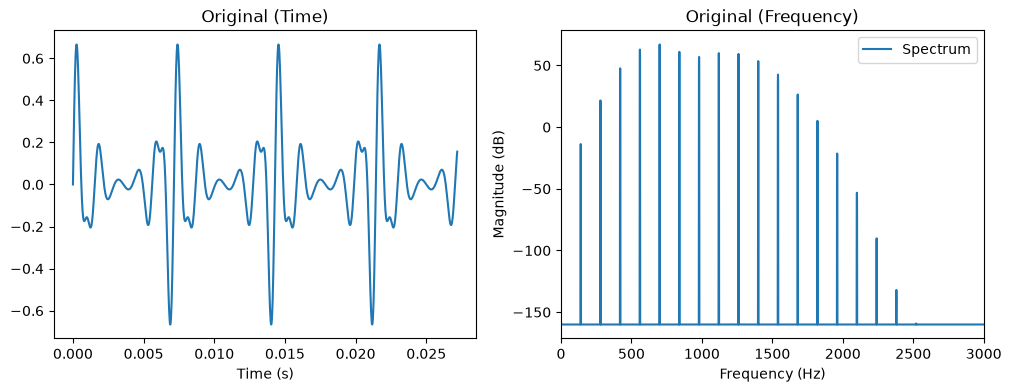

array([-1.15809078e-14+0.00000000e+00j,  1.21807865e-14+8.51872209e-15j,
       -1.60984947e-16-6.00046639e-15j, ...,
        2.41688718e-15+9.85245688e-16j, -1.31597054e-14-1.84950836e-15j,
        7.51492823e-15+0.00000000e+00j], shape=(22051,))

In [4]:
plot_time_and_spectrum(signal,"Original")

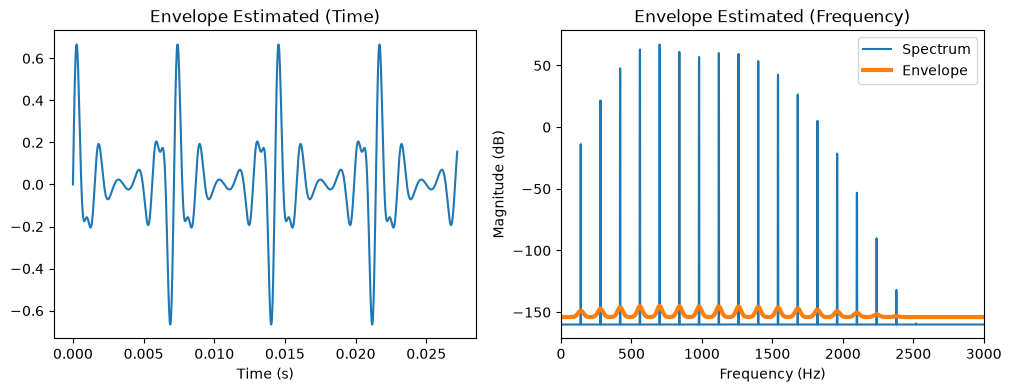

array([-1.15809078e-14+0.00000000e+00j,  1.21807865e-14+8.51872209e-15j,
       -1.60984947e-16-6.00046639e-15j, ...,
        2.41688718e-15+9.85245688e-16j, -1.31597054e-14-1.84950836e-15j,
        7.51492823e-15+0.00000000e+00j], shape=(22051,))

In [5]:
window = get_window("hann",len(signal))
X = np.fft.rfft(signal*window)

mag = np.abs(X)

log_mag = np.log(mag+1e-8)

sigma = 20

log_env = gaussian_filter1d(log_mag,sigma)

env = np.exp(log_env)

plot_time_and_spectrum(signal,
                       "Envelope Estimated",
                       env)

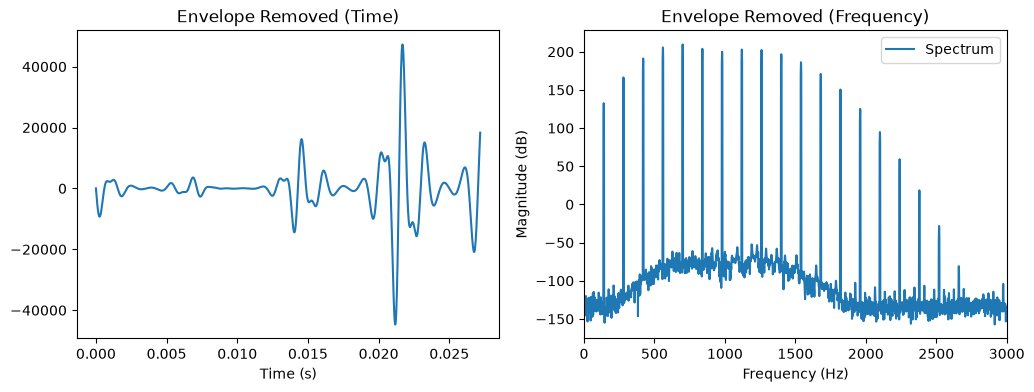

array([-4.36025992e-07+0.00000000e+00j,  5.13285931e-07+3.63762911e-07j,
       -2.26140308e-07-3.39298585e-07j, ...,
        2.84397084e-07+1.80296252e-07j, -6.88544829e-07-1.52884939e-07j,
        6.44308195e-07+0.00000000e+00j], shape=(22051,))

In [6]:
flattened_mag = mag/(env+1e-8)

flattened = np.fft.irfft(flattened_mag*np.exp(1j*np.angle(X)))

plot_time_and_spectrum(flattened,
                       "Envelope Removed")

In [7]:
Audio(flattened,rate=fs)

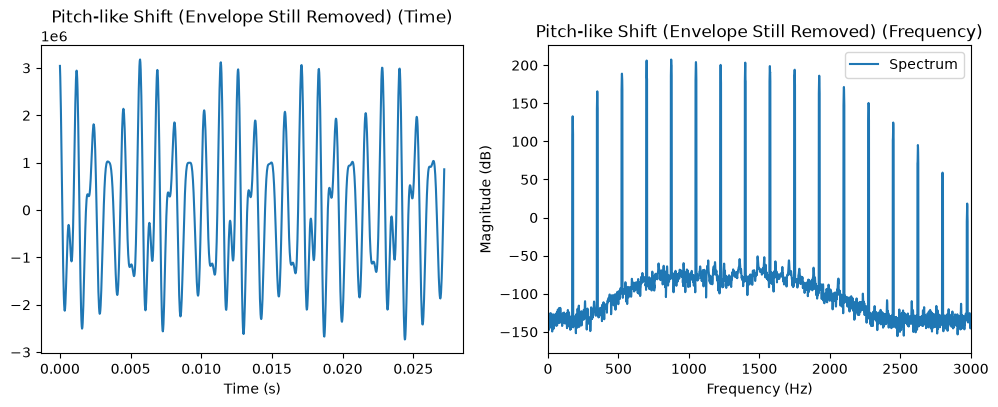

array([-4.69386578e-07+0.00000000e+00j,  5.19004306e-07+2.51563869e-07j,
       -2.29832524e-07-3.64718024e-07j, ...,
        3.21691245e-07+2.33658912e-07j, -6.97243233e-07-1.68516080e-07j,
        5.58793545e-07+0.00000000e+00j], shape=(22051,))

In [8]:
shift = 1.25

N = len(flattened_mag)

new_mag = np.zeros_like(flattened_mag)

old_bins = np.arange(len(flattened_mag))

src = old_bins/shift

new_mag = np.interp(src,
                    old_bins,
                    flattened_mag,
                    left=0,
                    right=0)

shifted = np.fft.irfft(new_mag*np.exp(1j*np.angle(X)))

plot_time_and_spectrum(shifted,
                       "Pitch-like Shift (Envelope Still Removed)")

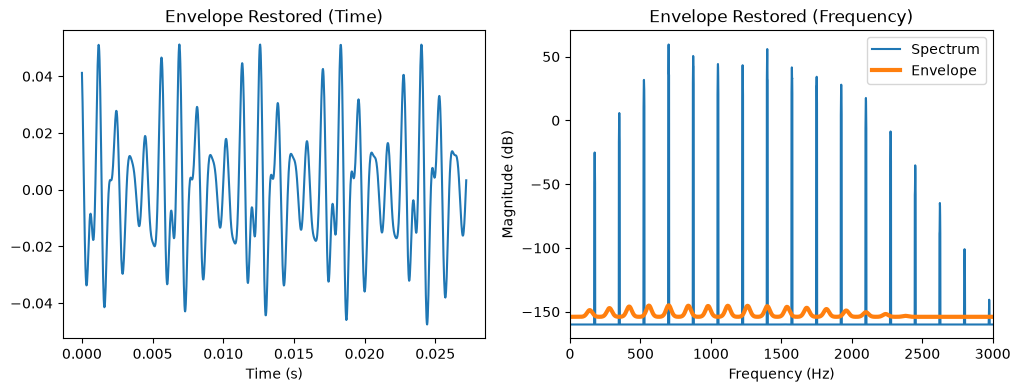

In [9]:
restored_mag = new_mag*env

restored = np.fft.irfft(restored_mag*np.exp(1j*np.angle(X)))

plot_time_and_spectrum(restored,
                       "Envelope Restored",
                       env)

Audio(restored,rate=fs)

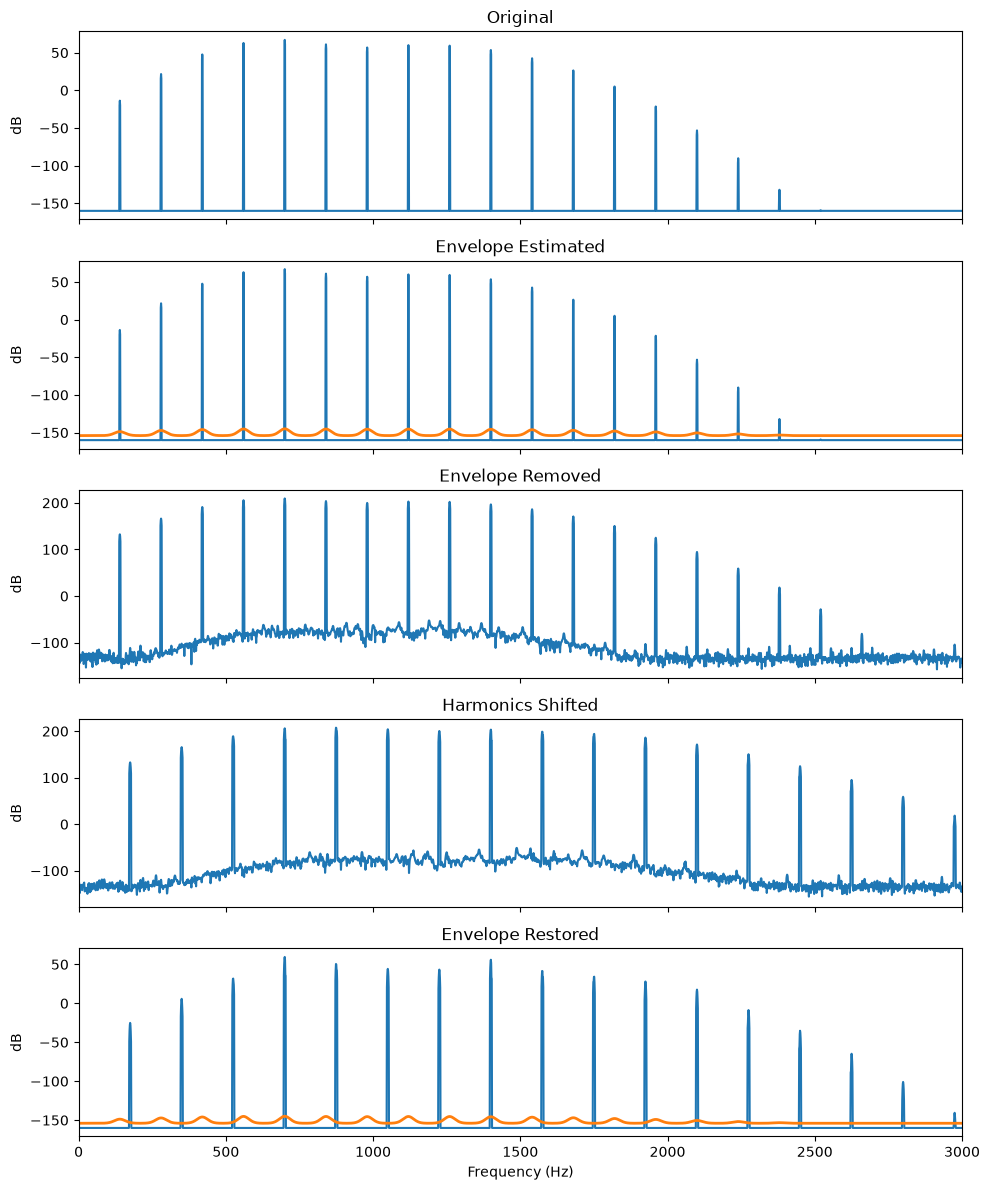

In [10]:
fig,axes=plt.subplots(5,1,figsize=(10,12),sharex=True)

titles=[
    "Original",
    "Envelope Estimated",
    "Envelope Removed",
    "Harmonics Shifted",
    "Envelope Restored"
]

signals=[
    signal,
    signal,
    flattened,
    shifted,
    restored
]

envelopes=[
    None,
    env,
    None,
    None,
    env
]

for ax,title,sig,e in zip(axes,titles,signals,envelopes):

    X=np.fft.rfft(sig*window)
    mag=np.abs(X)

    ax.plot(freqs,
            20*np.log10(mag+1e-8))

    if e is not None:
        ax.plot(freqs,
                20*np.log10(e+1e-8),
                linewidth=2)

    ax.set_xlim(0,3000)
    ax.set_ylabel("dB")
    ax.set_title(title)

axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()